In [1]:
!pip install wordcloud


In [2]:
# --------------------------------------------
# 1. IMPORT LIBRARIES
# --------------------------------------------

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
import string

from wordcloud import WordCloud

# NLP Libraries
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer

# Machine Learning
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer

from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import LinearSVC

# Evaluation Metrics
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)

# Download NLTK resources
nltk.download('punkt')
nltk.download('stopwords')
nltk.download('wordnet')



[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\akshi\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\akshi\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\akshi\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


True

In [3]:
# --------------------------------------------
# 2. LOAD DATASET
# --------------------------------------------

df = pd.read_excel("Sentiment Analysis Dataset.xlsx")

# Display first 5 rows
df.head()

,title,rating,body
0,Horrible product,1,Very disappointed with the overall performance...
1,Camera quality is not like 48 megapixel,3,Camera quality is low
2,Overall,4,"Got the mobile on the launch date,Battery must..."
3,A big no from me,1,1. It doesn't work with 5.0GHz WiFi frequency....
4,Put your money somewhere else,1,"Not worth buying....faulty software, poor disp..."


In [4]:
# 3. DATASET OVERVIEW (EDA)
# --------------------------------------------

# Dataset Shape
print("Dataset Shape:", df.shape)

# Dataset Information
print("\nDataset Info:\n")
print(df.info())

# Missing Values
print("\nMissing Values:\n")
print(df.isnull().sum())

# Duplicate Check
print("\nDuplicate Rows:", df.duplicated().sum())

# Remove duplicates
df.drop_duplicates(inplace=True)


Dataset Shape: (1440, 3)

Dataset Info:

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1440 entries, 0 to 1439
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   title   1440 non-null   object
 1   rating  1440 non-null   int64 
 2   body    1440 non-null   object
dtypes: int64(1), object(2)
memory usage: 33.9+ KB
None

Missing Values:

title     0
rating    0
body      0
dtype: int64

Duplicate Rows: 0


In [5]:
# --------------------------------------------
# 4. COLUMN NAMES
# --------------------------------------------

print("\nColumns in Dataset:")
print(df.columns)


Columns in Dataset:
Index(['title', 'rating', 'body'], dtype='object')


In [6]:
# --------------------------------------------
# 5. RENAME COLUMNS (EDIT IF NEEDED)
# --------------------------------------------

# Rename columns based on your dataset
df.rename(columns={
    'title': 'title',
    'body': 'review',
    'rating': 'rating'
}, inplace=True)

# Create sentiment column from rating
# Positive = 4,5
# Neutral = 3
# Negative = 1,2

def get_sentiment(rating):
    if rating >= 4:
        return "Positive"
    elif rating == 3:
        return "Neutral"
    else:
        return "Negative"

df['sentiment'] = df['rating'].apply(get_sentiment)

# Check first few rows
print(df[['title', 'review', 'rating', 'sentiment']].head())

                                     title  \
0                         Horrible product   
1  Camera quality is not like 48 megapixel   
2                                  Overall   
3                         A big no from me   
4            Put your money somewhere else   

                                              review  rating sentiment  
0  Very disappointed with the overall performance...       1  Negative  
1                              Camera quality is low       3   Neutral  
2  Got the mobile on the launch date,Battery must...       4  Positive  
3  1. It doesn't work with 5.0GHz WiFi frequency....       1  Negative  
4  Not worth buying....faulty software, poor disp...       1  Negative  


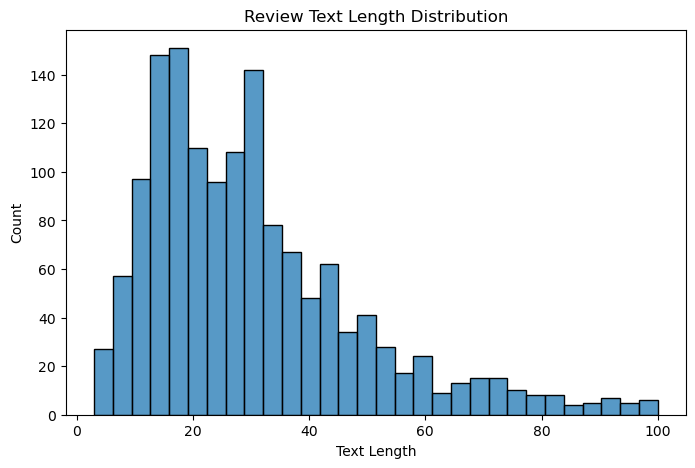

In [7]:
# --------------------------------------------
# 6. TEXT LENGTH ANALYSIS
# --------------------------------------------

df['text_length'] = df['title'].astype(str).apply(len)

plt.figure(figsize=(8,5))
sns.histplot(df['text_length'], bins=30)
plt.title("Review Text Length Distribution")
plt.xlabel("Text Length")
plt.ylabel("Count")
plt.show()

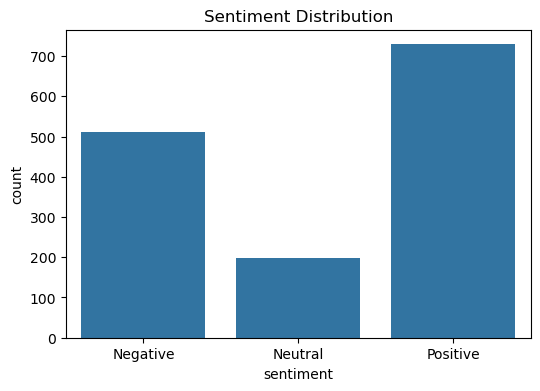

In [8]:
# --------------------------------------------
# 7. SENTIMENT DISTRIBUTION
# --------------------------------------------

plt.figure(figsize=(6,4))
sns.countplot(x='sentiment', data=df)
plt.title("Sentiment Distribution")
plt.show()

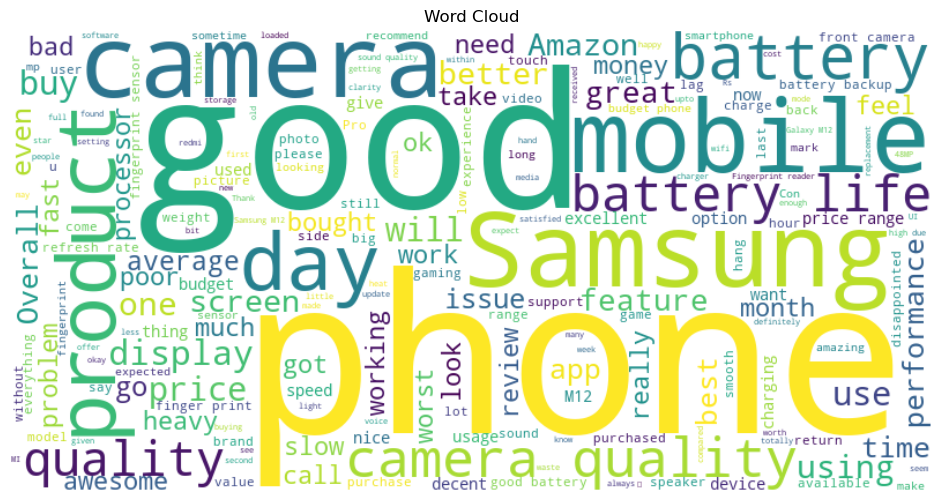

In [9]:
# --------------------------------------------
# 8. WORD CLOUD
# --------------------------------------------

all_text = " ".join(df['review'].astype(str))

wordcloud = WordCloud(
    width=800,
    height=400,
    background_color='white'
).generate(all_text)

plt.figure(figsize=(12,6))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title("Word Cloud")
plt.show()

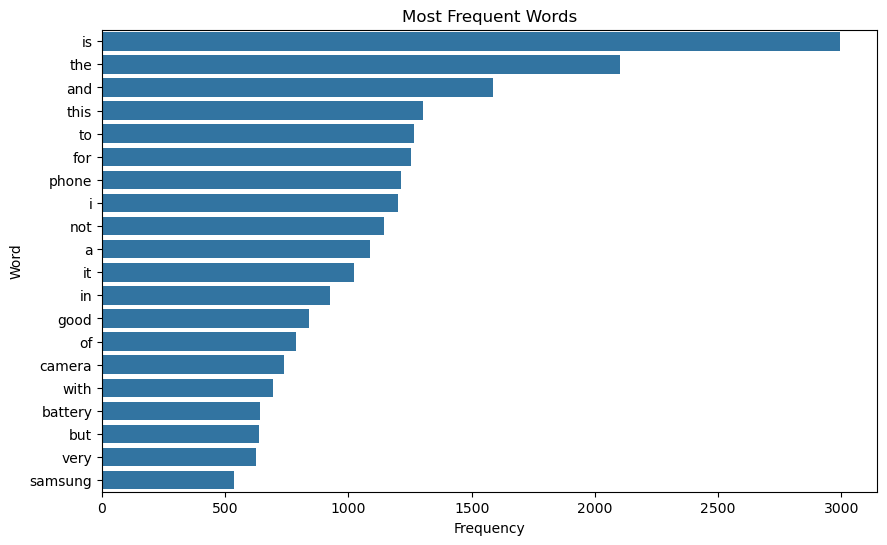

In [10]:
# --------------------------------------------
# 9. MOST FREQUENT WORDS
# --------------------------------------------

from collections import Counter

words = all_text.lower().split()

common_words = Counter(words).most_common(20)

common_df = pd.DataFrame(common_words, columns=['Word', 'Frequency'])

plt.figure(figsize=(10,6))
sns.barplot(x='Frequency', y='Word', data=common_df)
plt.title("Most Frequent Words")
plt.show()

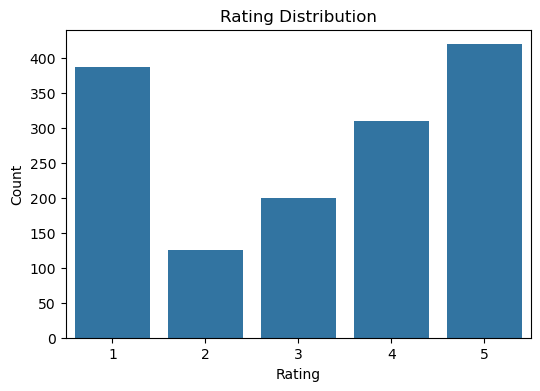

In [11]:
# --------------------------------------------
# 10. RATING DISTRIBUTION (IF AVAILABLE)
# --------------------------------------------

if 'rating' in df.columns:
    plt.figure(figsize=(6,4))
    sns.countplot(x='rating', data=df)
    plt.title("Rating Distribution")
    plt.xlabel("Rating")
    plt.ylabel("Count")
    plt.show()

In [12]:
# --------------------------------------------
# 11. TEXT PREPROCESSING
# --------------------------------------------

stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

def preprocess_text(text):
    
    # Convert to lowercase
    text = text.lower()
    
    # Remove punctuation and numbers
    text = re.sub(r'[^a-zA-Z\s]', '', text)
    
    # Tokenization
    tokens = word_tokenize(text)
    
    # Remove stopwords and lemmatize
    cleaned_tokens = [
        lemmatizer.lemmatize(word)
        for word in tokens
        if word not in stop_words
    ]
    
    return " ".join(cleaned_tokens)

# Apply preprocessing
df['cleaned_review'] = df['review'].astype(str).apply(preprocess_text)

# Display cleaned text
df[['review', 'cleaned_review']].head()


,review,cleaned_review
0,Very disappointed with the overall performance...,disappointed overall performance samsung
1,Camera quality is low,camera quality low
2,"Got the mobile on the launch date,Battery must...",got mobile launch datebattery must appreciated...
3,1. It doesn't work with 5.0GHz WiFi frequency....,doesnt work ghz wifi frequency ghz old school ...
4,"Not worth buying....faulty software, poor disp...",worth buyingfaulty software poor display quali...


In [13]:
# --------------------------------------------
# 12. FEATURE ENGINEERING - TF-IDF
# --------------------------------------------

tfidf = TfidfVectorizer(max_features=5000)

X = tfidf.fit_transform(df['cleaned_review'])

y = df['sentiment']


In [14]:
# --------------------------------------------
# 13. TRAIN TEST SPLIT
# --------------------------------------------

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)


In [15]:
# --------------------------------------------
# 14. MODEL BUILDING
# --------------------------------------------

models = {
    "Logistic Regression": LogisticRegression(),
    "Naive Bayes": MultinomialNB(),
    "Random Forest": RandomForestClassifier(),
    "SVM": LinearSVC()
}

# Create empty list for results
results = []



MODEL: Logistic Regression
Accuracy : 0.7778
Precision: 0.8186
Recall   : 0.7778
F1 Score : 0.7245

Classification Report:

              precision    recall  f1-score   support

    Negative       0.86      0.86      0.86       111
     Neutral       1.00      0.05      0.09        44
    Positive       0.72      0.95      0.82       133

    accuracy                           0.78       288
   macro avg       0.86      0.62      0.59       288
weighted avg       0.82      0.78      0.72       288



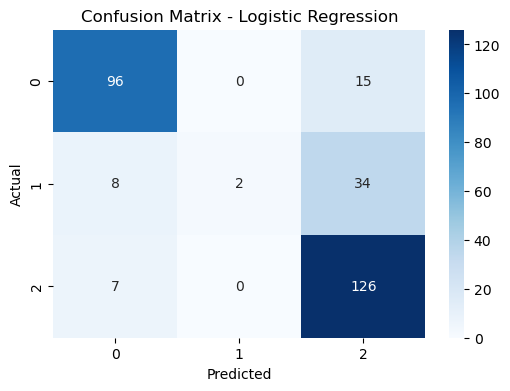


MODEL: Naive Bayes
Accuracy : 0.6736
Precision: 0.6410
Recall   : 0.6736
F1 Score : 0.6140

Classification Report:

              precision    recall  f1-score   support

    Negative       0.95      0.56      0.70       111
     Neutral       0.00      0.00      0.00        44
    Positive       0.59      0.99      0.74       133

    accuracy                           0.67       288
   macro avg       0.52      0.52      0.48       288
weighted avg       0.64      0.67      0.61       288



C:\Users\akshi\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\akshi\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\akshi\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\akshi\anaconda3\Lib

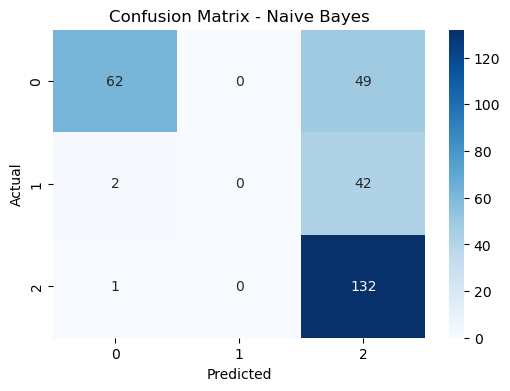


MODEL: Random Forest


C:\Users\akshi\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\akshi\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\akshi\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\akshi\anaconda3\Lib

Accuracy : 0.7431
Precision: 0.6383
Recall   : 0.7431
F1 Score : 0.6821

Classification Report:

              precision    recall  f1-score   support

    Negative       0.82      0.80      0.81       111
     Neutral       0.00      0.00      0.00        44
    Positive       0.69      0.94      0.80       133

    accuracy                           0.74       288
   macro avg       0.51      0.58      0.54       288
weighted avg       0.64      0.74      0.68       288



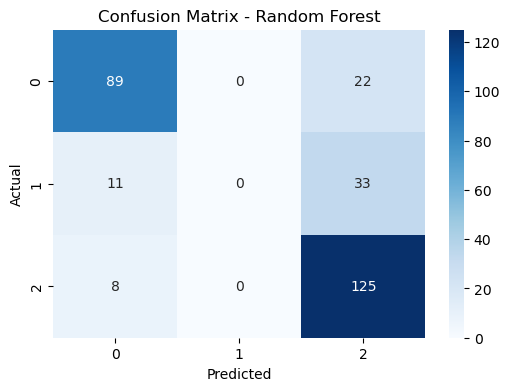


MODEL: SVM
Accuracy : 0.7674
Precision: 0.7412
Recall   : 0.7674
F1 Score : 0.7405

Classification Report:

              precision    recall  f1-score   support

    Negative       0.82      0.86      0.84       111
     Neutral       0.50      0.18      0.27        44
    Positive       0.75      0.88      0.81       133

    accuracy                           0.77       288
   macro avg       0.69      0.64      0.64       288
weighted avg       0.74      0.77      0.74       288



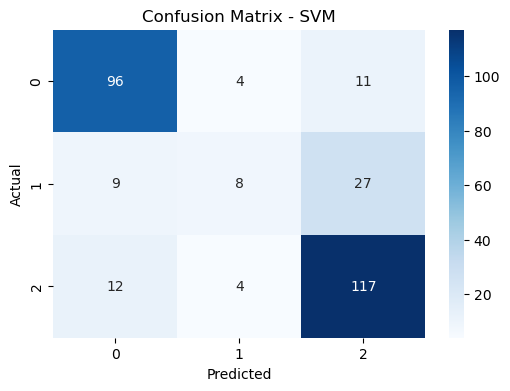

In [16]:
# --------------------------------------------
# 15. TRAINING & EVALUATION
# --------------------------------------------

for model_name, model in models.items():
    
    print("\n===================================")
    print(f"MODEL: {model_name}")
    print("===================================")
    
    # Train model
    model.fit(X_train, y_train)
    
    # Predictions
    y_pred = model.predict(X_test)
    
    # Metrics
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred, average='weighted')
    recall = recall_score(y_test, y_pred, average='weighted')
    f1 = f1_score(y_test, y_pred, average='weighted')
    
    # Store results
    results.append({
        'Model': model_name,
        'Accuracy': accuracy,
        'Precision': precision,
        'Recall': recall,
        'F1 Score': f1
    })
    
    # Print Scores
    print(f"Accuracy : {accuracy:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall   : {recall:.4f}")
    print(f"F1 Score : {f1:.4f}")
    
    # Classification Report
    print("\nClassification Report:\n")
    print(classification_report(y_test, y_pred))
    
    # Confusion Matrix
    cm = confusion_matrix(y_test, y_pred)
    
    plt.figure(figsize=(6,4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.title(f'Confusion Matrix - {model_name}')
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()


In [17]:

# --------------------------------------------
# 16. MODEL COMPARISON TABLE
# --------------------------------------------

results_df = pd.DataFrame(results)

print("\nMODEL COMPARISON TABLE\n")
print(results_df)



MODEL COMPARISON TABLE

                 Model  Accuracy  Precision    Recall  F1 Score
0  Logistic Regression  0.777778   0.818611  0.777778  0.724459
1          Naive Bayes  0.673611   0.640984  0.673611  0.614006
2        Random Forest  0.743056   0.638310  0.743056  0.682115
3                  SVM  0.767361   0.741217  0.767361  0.740519


In [18]:
# --------------------------------------------
# 17. BEST MODEL SELECTION
# --------------------------------------------

best_model = results_df.sort_values(
    by='Accuracy',
    ascending=False
).iloc[0]

print("\n===================================")
print("BEST PERFORMING MODEL")
print("===================================")

print("Model Name :", best_model['Model'])
print("Accuracy   :", round(best_model['Accuracy'], 4))
print("Precision  :", round(best_model['Precision'], 4))
print("Recall     :", round(best_model['Recall'], 4))
print("F1 Score   :", round(best_model['F1 Score'], 4))



BEST PERFORMING MODEL
Model Name : Logistic Regression
Accuracy   : 0.7778
Precision  : 0.8186
Recall     : 0.7778
F1 Score   : 0.7245


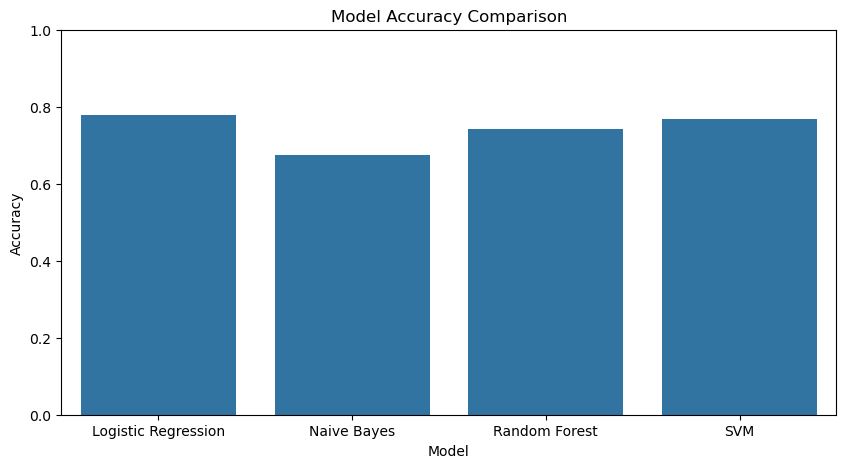

In [19]:
# --------------------------------------------
# 18. VISUALIZE MODEL COMPARISON
# --------------------------------------------

plt.figure(figsize=(10,5))
sns.barplot(x='Model', y='Accuracy', data=results_df)
plt.title("Model Accuracy Comparison")
plt.ylim(0,1)
plt.show()

In [20]:
# --------------------------------------------
# 19. SAVE BEST MODEL (OPTIONAL)
# --------------------------------------------

import joblib

# Train best model again
best_model_name = best_model['Model']
final_model = models[best_model_name]

final_model.fit(X_train, y_train)

# Save model and vectorizer
joblib.dump(final_model, "best_sentiment_model.pkl")
joblib.dump(tfidf, "tfidf_vectorizer.pkl")

print("\nModel and Vectorizer Saved Successfully!")



Model and Vectorizer Saved Successfully!


In [21]:
# --------------------------------------------
# 20. TEST CUSTOM REVIEW
# --------------------------------------------

sample_review = ["This product is amazing and very useful"]

# Preprocess
clean_review = [preprocess_text(text) for text in sample_review]

# Vectorize
vectorized_review = tfidf.transform(clean_review)

# Prediction
prediction = final_model.predict(vectorized_review)

print("\nCustom Review Prediction:")
print("Review:", sample_review[0])
print("Predicted Sentiment:", prediction[0])


Custom Review Prediction:
Review: This product is amazing and very useful
Predicted Sentiment: Positive


In [27]:
import joblib

# Save trained model
joblib.dump(final_model, "best_sentiment_model.pkl")

# Save TF-IDF vectorizer
joblib.dump(tfidf, "tfidf_vectorizer.pkl")

print("Model and Vectorizer Saved Successfully!")


Model and Vectorizer Saved Successfully!


In [28]:
import os

print(os.listdir())

['.ipynb_checkpoints', 'best_sentiment_model.pkl', 'NLP1 - Copy.ipynb', 'tfidf_vectorizer.pkl', 'Untitled.ipynb']


In [29]:
import streamlit as st
import joblib

# Load model and vectorizer
model = joblib.load("best_sentiment_model.pkl")
vectorizer = joblib.load("tfidf_vectorizer.pkl")

# Title
st.title("Sentiment Analysis App")

# User Input
review = st.text_area("Enter Review")

# Predict Button
if st.button("Predict"):
    
    review_vector = vectorizer.transform([review])
    
    prediction = model.predict(review_vector)
    
    st.success(f"Predicted Sentiment: {prediction[0]}")

2026-06-12 17:33:51.040 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-06-12 17:33:51.043 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-06-12 17:33:51.048 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-06-12 17:33:51.054 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-06-12 17:33:51.058 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-06-12 17:33:51.061 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-06-12 17:33:51.065 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-06-12 17:33:51.073 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bar